<a href="https://colab.research.google.com/github/rjlobosco/unifesp/blob/main/Aula_TVI_Bolzano_Bissecao_GeoGebra(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 5 — Teorema do Valor Intermediário e Método da Bisseção
## Fundamentação matemática, investigação no GeoGebra e implementação em Python

**Disciplina:** Métodos Numéricos — nível de graduação avançada/pós-graduação  
**Ambiente:** Google Colab + GeoGebra  




Ao final da aula, você deverá ser capaz de:

- enunciar o Teorema do Valor Intermediário (TVI);
- interpretar o TVI em termos geométricos e de conexidade;
- reconhecer o Teorema de Bolzano como o caso particular $L=0$;
- verificar criticamente as hipóteses de continuidade e mudança de sinal;
- distinguir **existência**, **unicidade**, **localização** e **aproximação numérica** de uma raiz;
- investigar os teoremas no GeoGebra;
- formular o método da bisseção a partir de um invariante matemático;
- implementar, testar e analisar o erro do método;
- reconhecer situações em que o teste de mudança de sinal é inconclusivo ou inválido.



In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25
})




Considere a equação:

$$x^3-x-2=0.$$

Definimos:

$$f(x)=x^3-x-2.$$

Resolver a equação significa encontrar um número $x^*$ para o qual:

$$f(x^*)=0.$$

Esse número é chamado de **raiz** ou **zero da função**.

Antes de calcular a raiz, precisamos responder:

1. existe uma raiz em determinado intervalo?
2. quais hipóteses permitem afirmar sua existência?
3. como aproximar seu valor?

Os teoremas respondem à questão da **existência**. O método da bisseção responde à questão do **cálculo aproximado**.


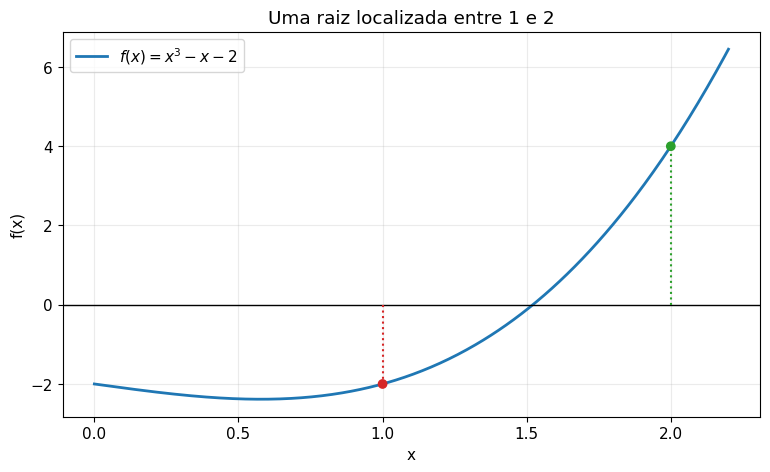

f(1) = -2
f(2) = 4
f(1)·f(2) = -8


In [2]:
def f(x):
    return x**3 - x - 2

x = np.linspace(0, 2.2, 500)
plt.plot(x, f(x), linewidth=2, label=r"$f(x)=x^3-x-2$")
plt.axhline(0, color="black", linewidth=1)
plt.scatter([1, 2], [f(1), f(2)], color=["tab:red", "tab:green"], zorder=3)
plt.vlines([1, 2], 0, [f(1), f(2)], colors=["tab:red", "tab:green"], linestyles=":")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title("Uma raiz localizada entre 1 e 2")
plt.legend(); plt.show()

print(f"f(1) = {f(1)}")
print(f"f(2) = {f(2)}")
print(f"f(1)·f(2) = {f(1)*f(2)}")


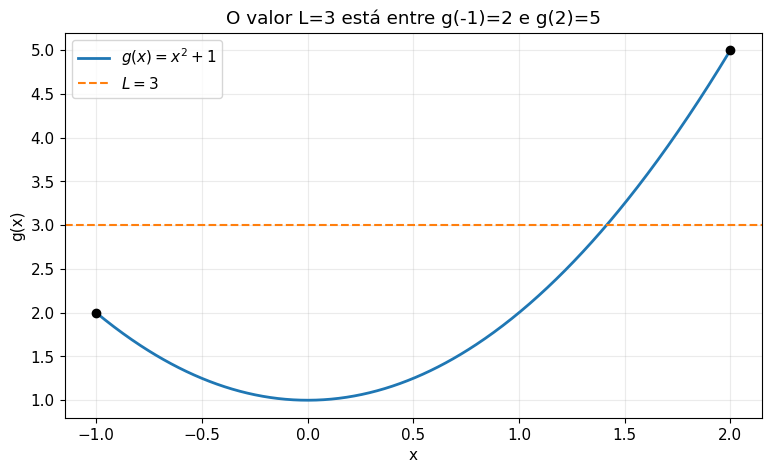

g(-1) = 2.0
g(2)  = 5.0
Um ponto com g(c)=3 é c = 1.4142135623730951


In [3]:
# Exemplo do TVI: f(x)=x²+1 em [-1,2], com L=3.
def g(x):
    return x**2 + 1

a_tvi, b_tvi, L_tvi = -1.0, 2.0, 3.0
x = np.linspace(a_tvi, b_tvi, 500)
plt.plot(x, g(x), linewidth=2, label=r"$g(x)=x^2+1$")
plt.axhline(L_tvi, color="tab:orange", linestyle="--", label=r"$L=3$")
plt.scatter([a_tvi, b_tvi], [g(a_tvi), g(b_tvi)], color="black", zorder=3)
plt.xlabel("x"); plt.ylabel("g(x)")
plt.title("O valor L=3 está entre g(-1)=2 e g(2)=5")
plt.legend(); plt.show()

print("g(-1) =", g(a_tvi))
print("g(2)  =", g(b_tvi))
print("Um ponto com g(c)=3 é c =", np.sqrt(2))


## 2. Teorema do Valor Intermediário

Seja

$$
f:[a,b]\longrightarrow\mathbb{R}
$$

uma função contínua em um intervalo fechado $[a,b]$. Para todo número real $L$ situado entre $f(a)$ e $f(b)$, existe pelo menos um ponto $c\in[a,b]$ tal que

$$
\boxed{f(c)=L}.
$$

Equivalentemente, se

$$
\min\{f(a),f(b)\}\leq L\leq\max\{f(a),f(b)\},
$$

então

$$
\exists\,c\in[a,b]\quad\text{tal que}\quad f(c)=L.
$$

Se $L$ estiver estritamente entre $f(a)$ e $f(b)$, então pelo menos um desses pontos pertence ao interior do intervalo:

$$
c\in(a,b).
$$

### Interpretação matemática

O teorema afirma que a imagem de um intervalo por uma função contínua não apresenta lacunas. Assim, se a função assume dois valores distintos nas extremidades, ela necessariamente assume todos os valores intermediários.



### Interpretação geométrica

Considere a reta horizontal

$$
y=L.
$$

Se o gráfico de uma função contínua está abaixo dessa reta em uma extremidade e acima dela na outra, então o gráfico necessariamente intercepta a reta em pelo menos um ponto do intervalo.

A interseção possui coordenadas

$$
(c,L),
$$

com

$$
f(c)=L.
$$

O teorema estabelece a existência da interseção, mas não fornece necessariamente sua localização exata.

---

## 2.1 Caso particular: Teorema de Bolzano

Um caso fundamental ocorre quando

$$
L=0.
$$

Se $f$ é contínua em $[a,b]$ e

$$
f(a)f(b)<0,
$$

então $f(a)$ e $f(b)$ possuem sinais opostos. Como zero está estritamente entre esses valores, existe pelo menos um ponto $c\in(a,b)$ tal que

$$
\boxed{f(c)=0}.
$$

Esse resultado é frequentemente chamado de **Teorema de Bolzano**:

$$
f\in C([a,b])
\quad\text{e}\quad
f(a)f(b)<0
\quad\Longrightarrow\quad
\exists\,c\in(a,b):f(c)=0.
$$

A notação

$$
f\in C([a,b])
$$

indica que $f$ pertence ao conjunto das funções contínuas no intervalo $[a,b]$.

---

## 2.2 Exemplo

Considere

$$
f(x)=x^3-x-2
$$

no intervalo $[1,2]$.

Como $f$ é uma função polinomial,

$$
f\in C([1,2]).
$$

Nas extremidades,

$$
f(1)=1^3-1-2=-2
$$

e

$$
f(2)=2^3-2-2=4.
$$

Consequentemente,

$$
f(1)f(2)=(-2)(4)=-8<0.
$$

Pelo Teorema de Bolzano, existe pelo menos um ponto

$$
c\in(1,2)
$$

tal que

$$
f(c)=0.
$$

Portanto, a equação

$$
x^3-x-2=0
$$

possui pelo menos uma solução no intervalo $(1,2)$.

O valor aproximado dessa raiz é

$$
c\approx1{,}5213797.
$$

Esse valor aproximado não é fornecido pelo teorema. Ele precisa ser determinado por um método numérico, como o método da bisseção.

---

## 2.3 Existência, unicidade e aproximação

É importante distinguir três questões diferentes.

| Questão                            | Resultado ou procedimento    |
| ---------------------------------- | ---------------------------- |
| Existe uma raiz no intervalo?      | Teorema de Bolzano           |
| A raiz é única?                    | Exige uma hipótese adicional |
| Qual é o valor aproximado da raiz? | Método numérico              |

O Teorema de Bolzano garante a existência de **pelo menos uma raiz**, mas não garante sua unicidade.

Por exemplo,

$$
p(x)=x^3-x
$$

é contínua em $[-2,2]$ e possui três raízes:

$$
x=-1,\qquad x=0,\qquad x=1.
$$

Para estabelecer unicidade em determinado intervalo, pode-se acrescentar uma condição como a monotonicidade estrita. Se, por exemplo,

$$
f'(x)>0
\qquad\text{para todo }x\in(a,b),
$$

então $f$ é estritamente crescente e pode possuir, no máximo, uma raiz nesse intervalo.

Assim, continuidade e mudança de sinal garantem existência;

---

## 2.4 Papel das hipóteses

As hipóteses do teorema não são meramente técnicas. Cada uma desempenha um papel específico.

### Continuidade no intervalo completo

A função deve estar definida e ser contínua em todos os pontos de $[a,b]$.

Considere

$$
q(x)=\frac{1}{x-1}
$$

no intervalo $[0,2]$.

Temos

$$
q(0)=-1
\qquad\text{e}\qquad
q(2)=1.
$$

Embora ocorra uma mudança de sinal, a função não é contínua em $x=1$. Portanto, o Teorema de Bolzano não pode ser aplicado.

A mudança de sinal é causada por uma singularidade, e não pela existência de uma raiz.

### Mudança estrita de sinal

A condição

$$
f(a)f(b)<0
$$

é suficiente para garantir pelo menos uma raiz, desde que a função seja contínua.

Entretanto, essa condição não é necessária para que uma raiz exista. Considere

$$
r(x)=(x-1)^2.
$$

No intervalo $[0,2]$,

$$
r(0)=1
\qquad\text{e}\qquad
r(2)=1.
$$

Logo,

$$
r(0)r(2)>0.
$$

Mesmo sem mudança de sinal, existe uma raiz em $x=1$. Nesse caso, a função toca o eixo horizontal, mas não o atravessa.

Portanto, a ausência de mudança de sinal não permite concluir que não existem raízes.


# 3. Teorema de Bolzano

O Teorema de Bolzano é a especialização do TVI ao nível $L=0$.

Se

$$f\in C([a,b])\qquad\text{e}\qquad f(a)f(b)<0,$$

então existe pelo menos um $c\in(a,b)$ tal que $f(c)=0$.

A condição $f(a)f(b)<0$ informa que os valores nas extremidades têm sinais opostos; logo, zero está estritamente entre $f(a)$ e $f(b)$. A continuidade permite aplicar o TVI.

## Verificação das hipóteses

1. **Domínio:** $f$ está definida em todos os pontos de $[a,b]$?
2. **Continuidade:** há justificativa matemática para $f\in C([a,b])$?
3. **Mudança de sinal:** vale realmente $f(a)f(b)<0$?
4. **Conclusão adequada:** estamos afirmando existência, e não unicidade?

## Exemplo principal

Para $f(x)=x^3-x-2$, a continuidade decorre de $f$ ser polinomial. Além disso,

$$f(1)=-2<0,\qquad f(2)=4>0.$$

Logo, Bolzano garante pelo menos uma raiz $c\in(1,2)$. O valor $c\approx1{,}5213797$ será obtido numericamente; ele **não** é fornecido pelo teorema.

> Em cálculo numérico, Bolzano funciona como certificado de existência e como base para manter uma raiz confinada em intervalos sucessivos.


In [4]:
def verificar_bolzano(funcao, a, b, continuidade_justificada=False):
    # O programa verifica valores e sinais. A continuidade deve ser
    # justificada matematicamente pelo usuário.
    fa, fb = funcao(a), funcao(b)
    mudanca = np.isfinite([fa, fb]).all() and fa*fb < 0
    return pd.DataFrame([{
        "a": a, "b": b, "f(a)": fa, "f(b)": fb,
        "continuidade justificada": continuidade_justificada,
        "mudança de sinal": mudanca,
        "Bolzano aplicável": continuidade_justificada and mudanca
    }])

display(verificar_bolzano(f, 1, 2, continuidade_justificada=True))


,a,b,f(a),f(b),continuidade justificada,mudança de sinal,Bolzano aplicável
0,1,2,-2,4,True,True,True


## Existência, unicidade, localização e aproximação

Essas quatro perguntas devem ser tratadas separadamente:

| Pergunta | Ferramenta ou informação necessária |
|---|---|
| Existe pelo menos uma raiz? | Bolzano, quando suas hipóteses são satisfeitas |
| A raiz é única? | Condição adicional, como monotonicidade estrita |
| Em qual intervalo está a raiz? | Intervalo com mudança de sinal e continuidade |
| Qual é seu valor aproximado? | Método numérico, como a bisseção |

Para $f(x)=x^3-x-2$, Bolzano garante existência em $(1,2)$. Para justificar unicidade, observe que

$$f'(x)=3x^2-1>0,\qquad x\in[1,2].$$

Assim, $f$ é estritamente crescente no intervalo e pode cruzar o eixo horizontal no máximo uma vez. Combinando existência e monotonicidade, há **exatamente uma** raiz em $(1,2)$.

> Como $f$ é contínua em $[1,2]$ e $f(1)f(2)<0$, Bolzano garante ao menos uma raiz. Como $f'(x)>0$ no intervalo, a raiz é única. A bisseção será usada para aproximá-la.

A mudança de sinal isoladamente não garante unicidade.


# 4. Atividade guiada no GeoGebra — Teorema do Valor Intermediário

Acesse a [Calculadora Gráfica do GeoGebra](https://www.geogebra.org/calculator).

Digite cada expressão separadamente na barra de entrada e pressione **Enter**.

### Passo 1 — Definir a função

Digite:

`g(x) = x^2 + 1`

Observe o gráfico da função.

### Passo 2 — Definir o intervalo

Digite:

`a = -1`

`b = 2`

O GeoGebra criará os números $a$ e $b$. Se desejar, use a opção **Criar controle deslizante**.

### Passo 3 — Criar as extremidades do gráfico

Digite:

`A = (a, g(a))`

`B = (b, g(b))`

Confira na janela algébrica:

$$g(-1)=2,\qquad g(2)=5.$$

### Passo 4 — Escolher um valor intermediário

Digite:

`L = 3`

Crie a reta horizontal:

`y = L`

### Passo 5 — Observar a interseção

Selecione a ferramenta **Interseção** e clique na parábola e na reta $y=L$.

Perguntas:

1. A reta encontra o gráfico dentro de $[-1,2]$?
2. Qual é aproximadamente o valor de $c$?
3. O ponto encontrado é único no intervalo?

### Passo 6 — Testar outros valores de L

Transforme $L$ em controle deslizante com mínimo 2 e máximo 5. Movimente-o lentamente.

Registre o que ocorre para $L=2$, $L=2{,}5$, $L=4$ e $L=5$.

### Conclusão esperada

Para cada $L$ situado entre $g(a)=2$ e $g(b)=5$, existe pelo menos um ponto $c\in[-1,2]$ para o qual $g(c)=L$.


# 5. Atividade guiada no GeoGebra — Bolzano e bisseção

Abra uma nova construção ou apague os objetos anteriores.

### Passo 1 — Inserir a função

`f(x) = x^3 - x - 2`

### Passo 2 — Definir o intervalo

`a = 1`

`b = 2`

### Passo 3 — Criar os pontos das extremidades

`A = (a, f(a))`

`B = (b, f(b))`

Observe que $A$ está abaixo do eixo e $B$ está acima.

### Passo 4 — Marcar o intervalo no eixo x

Use a ferramenta **Segmento** para unir os pontos $(a,0)$ e $(b,0)$, ou digite:

`Segment((a,0),(b,0))`

Se a interface estiver em português, o GeoGebra poderá apresentar o nome traduzido do comando. Utilize a opção sugerida automaticamente pela barra de entrada.

### Passo 5 — Criar o primeiro ponto médio

`m1 = (a + b)/2`

`M1 = (m1, f(m1))`

Anote:

$$m_1=1{,}5,\qquad f(m_1)=-0{,}125.$$

### Passo 6 — Decidir qual metade conservar

Compare os sinais:

- $f(a)<0$;
- $f(m_1)<0$;
- $f(b)>0$.

A mudança de sinal está entre $m_1$ e $b$. O novo intervalo é $[1{,}5,2]$.

### Passo 7 — Fazer a segunda iteração

`a1 = m1`

`b1 = b`

`m2 = (a1 + b1)/2`

`M2 = (m2, f(m2))`

Verifique que $m_2=1{,}75$ e $f(m_2)>0$. Qual será o novo intervalo?

### Passo 8 — Fazer a terceira iteração

Crie $a_2$, $b_2$, $m_3$ e $M_3$ de acordo com a decisão anterior.

### Passo 9 — Conferir a raiz calculada pelo GeoGebra

Use a ferramenta **Raízes** ou digite, conforme a sugestão da sua interface:

`Root(f,1,2)`

O comando fornece numericamente uma raiz no intervalo. Compare com seus pontos médios. O objetivo do comando é conferir o resultado; ele não substitui a execução das iterações.


## Ficha para registrar o experimento no GeoGebra

Preencha durante a construção:

| Iteração | $a_k$ | $b_k$ | $m_k$ | $f(a_k)$ | $f(m_k)$ | $f(b_k)$ | Intervalo seguinte |
|---:|---:|---:|---:|---:|---:|---:|---|
| 1 |  |  |  |  |  |  |  |
| 2 |  |  |  |  |  |  |  |
| 3 |  |  |  |  |  |  |  |
| 4 |  |  |  |  |  |  |  |

Depois, responda:

1. Por que o intervalo continua contendo uma raiz?
2. O que ocorre com sua largura a cada iteração?
3. O GeoGebra provou que a função é contínua?
4. Qual propriedade da função justifica a continuidade neste exemplo?


# 6. Do GeoGebra para o algoritmo de bisseção

A bisseção transforma o argumento de existência em um procedimento construtivo. Partimos de $[a_0,b_0]$ tal que $f$ é contínua e $f(a_0)f(b_0)<0$.

Em cada iteração, calculamos $m_n=(a_n+b_n)/2$. Se $f(m_n)=0$, a raiz foi encontrada. Caso contrário, escolhemos a metade em cujas extremidades permanece a mudança de sinal.

## Invariante do método

A propriedade mantida em todas as iterações é

$$f(a_n)f(b_n)<0.$$

Sob continuidade, esse invariante certifica que cada intervalo $[a_n,b_n]$ contém pelo menos uma raiz. Os intervalos são encaixados,

$$[a_{n+1},b_{n+1}]\subset[a_n,b_n],$$

e suas larguras obedecem a

$$b_n-a_n=\frac{b_0-a_0}{2^n}.$$

Usando o ponto médio como aproximação,

$$|x^*-m_n|\leq\frac{b_n-a_n}{2}.$$

O GeoGebra visualiza a escolha das metades; o código Python automatiza a decisão e registra o histórico.


In [5]:
def bissecao(funcao, a, b, tolerancia=1e-8, max_iter=100):
    # Método da bisseção com registro das iterações.
    if a >= b:
        raise ValueError("É necessário fornecer a < b.")
    if tolerancia <= 0 or max_iter < 1:
        raise ValueError("Use tolerância positiva e max_iter >= 1.")

    fa, fb = funcao(a), funcao(b)
    if not np.isfinite([fa, fb]).all():
        raise ValueError("A função não é finita nas extremidades.")
    if fa == 0:
        return a, pd.DataFrame(), "a é raiz"
    if fb == 0:
        return b, pd.DataFrame(), "b é raiz"
    if fa*fb > 0:
        raise ValueError("Não há mudança de sinal nas extremidades.")

    historico = []
    for k in range(1, max_iter+1):
        m = a + (b-a)/2
        fm = funcao(m)
        erro = (b-a)/2
        historico.append({
            "iteração": k, "a": a, "b": b, "m": m,
            "f(a)": fa, "f(m)": fm, "f(b)": fb,
            "erro máximo": erro
        })

        if fm == 0 or erro <= tolerancia:
            motivo = "raiz exata" if fm == 0 else "tolerância"
            break

        if fa*fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    else:
        raise RuntimeError("Número máximo de iterações atingido.")

    return m, pd.DataFrame(historico), motivo


In [6]:
raiz, historico, motivo = bissecao(f, 1, 2, tolerancia=1e-8)
print(f"Raiz aproximada: {raiz:.12f}")
print(f"f(raiz): {f(raiz):.3e}")
print(f"Número de iterações: {len(historico)}")
print(f"Parada: {motivo}")
display(historico.head(6).round(8))


Raiz aproximada: 1.521379701793
f(raiz): -2.979e-08
Número de iterações: 27
Parada: tolerância


,iteração,a,b,m,f(a),f(m),f(b),erro máximo
0,1,1.0,2.00000,1.500000,-2.000,-0.125000,4.000000,0.500000
1,2,1.5,2.00000,1.750000,-0.125,1.609375,4.000000,0.250000
2,3,1.5,1.75000,1.625000,-0.125,0.666016,1.609375,0.125000
3,4,1.5,1.62500,1.562500,-0.125,0.252197,0.666016,0.062500
4,5,1.5,1.56250,1.531250,-0.125,0.059113,0.252197,0.031250
5,6,1.5,1.53125,1.515625,-0.125,-0.034054,0.059113,0.015625


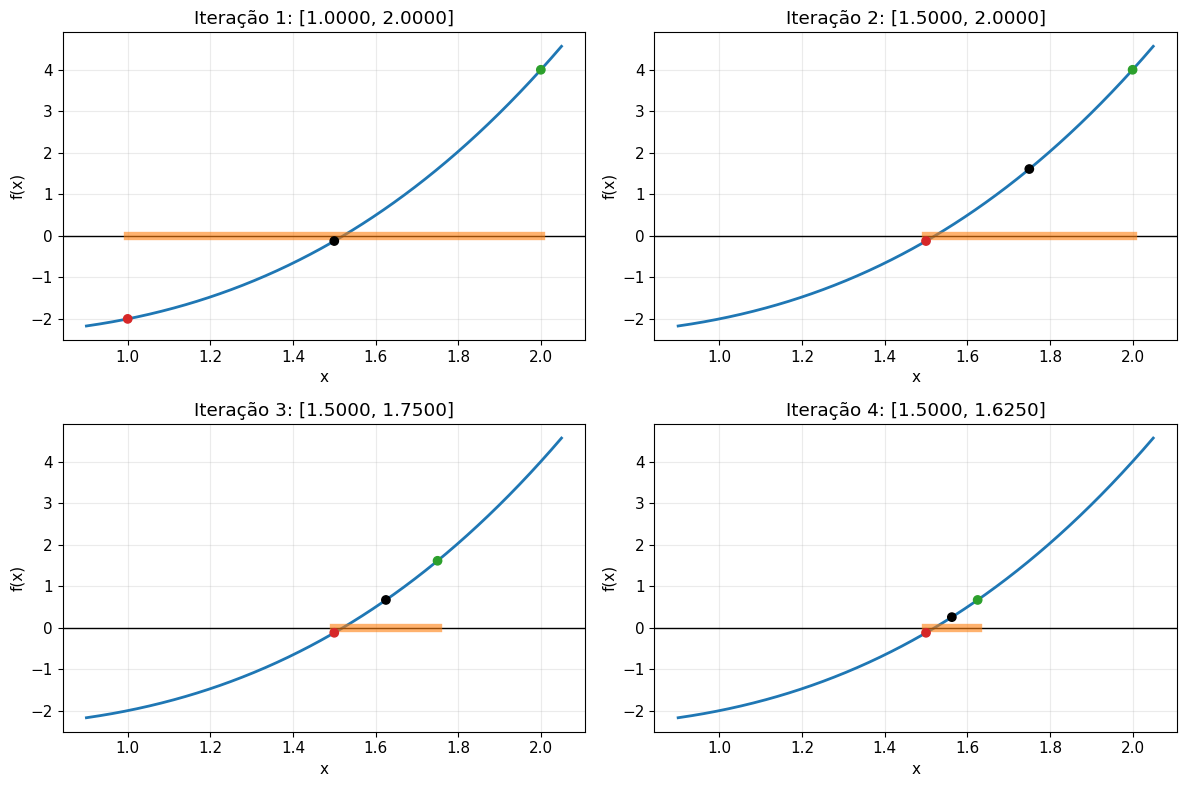

In [7]:
# Ilustração dos quatro primeiros intervalos.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x = np.linspace(0.9, 2.05, 500)

for ax, (_, linha) in zip(axes.flat, historico.iloc[:4].iterrows()):
    a, b, m = linha["a"], linha["b"], linha["m"]
    ax.plot(x, f(x), linewidth=2)
    ax.axhline(0, color="black", linewidth=1)
    ax.plot([a,b], [0,0], color="tab:orange", linewidth=6, alpha=0.6)
    ax.scatter([a,m,b], [f(a),f(m),f(b)],
               color=["tab:red","black","tab:green"], zorder=3)
    ax.set_title(f"Iteração {int(linha['iteração'])}: [{a:.4f}, {b:.4f}]")
    ax.set_xlabel("x"); ax.set_ylabel("f(x)")

plt.tight_layout(); plt.show()


# 7. Número de iterações e controle do erro

Se $L_0=b_0-a_0$ é a largura inicial, após $n$ reduções,

$$L_n=\frac{L_0}{2^n}.$$

Como a raiz $x^*$ e o ponto médio $m_n$ pertencem a $[a_n,b_n]$,

$$|x^*-m_n|\leq\frac{L_n}{2}=\frac{L_0}{2^{n+1}}.$$

A implementação deste notebook usa como critério conservador a **largura do intervalo**. Para garantir $b_n-a_n\leq\varepsilon$, é suficiente escolher

$$n_{\min}=\left\lceil\log_2\left(\frac{b_0-a_0}{\varepsilon}\right)\right\rceil.$$

Para $[1,2]$ e $\varepsilon=10^{-6}$, temos $n_{\min}=20$.

### Observação sobre critérios de parada

Podemos controlar a largura $b_n-a_n$, a meia largura $(b_n-a_n)/2$ ou o resíduo $|f(m_n)|$. Esses critérios não são equivalentes em geral. A tolerância deve sempre ser interpretada junto com o critério de parada adotado.


In [8]:
def iteracoes_garantidas(a, b, tolerancia):
    return max(1, math.ceil(math.log2((b-a)/tolerancia)))

for tol in [1e-2, 1e-4, 1e-6, 1e-8]:
    raiz_t, hist_t, _ = bissecao(f, 1, 2, tolerancia=tol)
    print(f"tol={tol:.0e} | garantia={iteracoes_garantidas(1,2,tol):2d} "
          f"| realizadas={len(hist_t):2d} | raiz={raiz_t:.10f}")


tol=1e-02 | garantia= 7 | realizadas= 7 | raiz=1.5234375000
tol=1e-04 | garantia=14 | realizadas=14 | raiz=1.5214233398
tol=1e-06 | garantia=20 | realizadas=20 | raiz=1.5213804245
tol=1e-08 | garantia=27 | realizadas=27 | raiz=1.5213797018


# 8. Testes que mostram a importância das hipóteses

Os exemplos distinguem uma condição **suficiente** de uma condição **necessária**.

## Caso A — existe raiz, mas não há mudança de sinal

Para $p(x)=(x-1)^2$ em $[0,2]$, temos $p(1)=0$, mas $p(0)p(2)=1>0$. Bolzano não se aplica com essas extremidades. Isso não prova ausência de raízes: a mudança de sinal é suficiente para detectar uma raiz sob continuidade, mas não é necessária. Raízes de multiplicidade par frequentemente apenas tangenciam o eixo.

## Caso B — há mudança de sinal, mas falta continuidade

Para $q(x)=1/(x-1)$ em $[0,2]$, temos $q(0)<0$ e $q(2)>0$, mas a função não está definida em $x=1$. A troca de sinal ocorre através de uma singularidade, não de um zero. Portanto, o produto negativo não pode ser usado sem continuidade em todo o intervalo.

## Caso C — produto nulo em uma extremidade

Se $f(a)f(b)=0$, então $a$ ou $b$ já é uma raiz. Esse caso deve ser tratado antes do teste estrito, como faz a implementação Python.

### Teste no GeoGebra

1. Digite `p(x) = (x-1)^2` e observe a tangência em $x=1$.
2. Digite `q(x) = 1/(x-1)` e identifique a assíntota vertical.
3. Para cada função, registre quais hipóteses de Bolzano são satisfeitas.
4. Explique por que a imagem gráfica auxilia a investigação, mas não substitui a justificativa de continuidade.


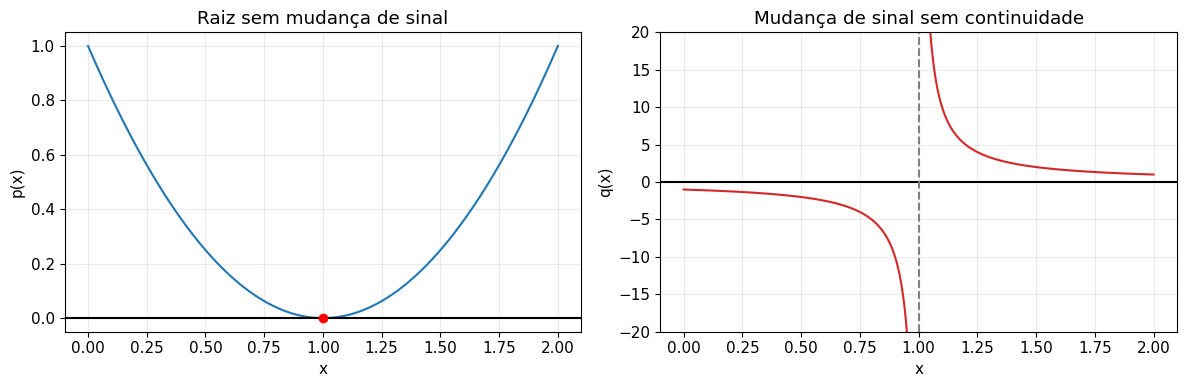

In [9]:
def p(x): return (x-1)**2
def q(x): return 1/(x-1)

x1 = np.linspace(0, 2, 500)
x2a = np.linspace(0, 0.97, 250)
x2b = np.linspace(1.03, 2, 250)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x1, p(x1)); axes[0].axhline(0, color="black")
axes[0].scatter([1],[0],color="red",zorder=3)
axes[0].set(title="Raiz sem mudança de sinal", xlabel="x", ylabel="p(x)")
axes[1].plot(x2a,q(x2a),color="tab:red"); axes[1].plot(x2b,q(x2b),color="tab:red")
axes[1].axhline(0,color="black"); axes[1].axvline(1,color="gray",linestyle="--")
axes[1].set(ylim=(-20,20),title="Mudança de sinal sem continuidade",xlabel="x",ylabel="q(x)")
plt.tight_layout(); plt.show()


# 9. Atividade para os alunos

Considere:

$$h(x)=\cos(x)-x$$

no intervalo $[0,1]$.

### Parte 1 — GeoGebra

1. Digite `h(x) = cos(x) - x`.
2. Crie $a=0$ e $b=1$.
3. Crie $A=(a,h(a))$ e $B=(b,h(b))$.
4. Verifique os sinais de $h(a)$ e $h(b)$.
5. Explique por que $h$ é contínua em $[0,1]$.
6. Escreva corretamente a conclusão de Bolzano.
7. Execute manualmente quatro iterações da bisseção.
8. Use o comando de raiz apenas para conferir a resposta.

### Parte 2 — Python

1. Faça o gráfico de $h$.
2. Use `verificar_bolzano`.
3. Aplique `bissecao` com tolerâncias $10^{-2}$, $10^{-4}$ e $10^{-8}$.
4. Construa uma tabela com raiz, $|h(x)|$ e iterações.
5. Explique como a tolerância afeta o custo computacional.


In [10]:
# Célula para os alunos.
def h(x):
    return np.cos(x) - x

# Complete o gráfico, a verificação das hipóteses e a tabela.


# 10. Solução da atividade

Consulte depois de realizar a tentativa.


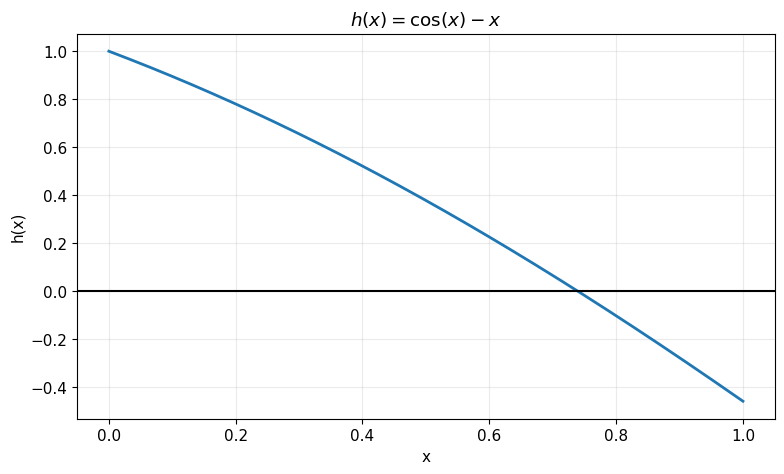

,a,b,f(a),f(b),continuidade justificada,mudança de sinal,Bolzano aplicável
0,0,1,1.0,-0.459698,True,True,True


,tolerância,raiz,|h(raiz)|,iterações
0,1.000000e-02,0.742188,5.195712e-03,7
1,1.000000e-04,0.739075,1.744935e-05,14
2,1.000000e-08,0.739085,4.722357e-09,27


In [11]:
x = np.linspace(0, 1, 400)
plt.plot(x, h(x), linewidth=2); plt.axhline(0,color="black")
plt.xlabel("x"); plt.ylabel("h(x)"); plt.title(r"$h(x)=\cos(x)-x$")
plt.show()

display(verificar_bolzano(h, 0, 1, continuidade_justificada=True))

resultados=[]
for tol in [1e-2,1e-4,1e-8]:
    raiz_h, hist_h, _ = bissecao(h,0,1,tolerancia=tol)
    resultados.append({"tolerância":tol,"raiz":raiz_h,
                       "|h(raiz)|":abs(h(raiz_h)),"iterações":len(hist_h)})
display(pd.DataFrame(resultados))


# 11. Referências e materiais complementares

## Python Programming and Numerical Methods

- [Índice geral — Python Numerical Methods](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html)
- [Capítulo 19.3 — Bisection Method](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter19.03-Bisection-Method.html)


## Numerical Analysis Notebooks

- [Repositório — Simone Brugiapaglia](https://github.com/simone-brugiapaglia/numerical-analysis-notebooks)
- [Notebook 03 — Bisection](https://github.com/simone-brugiapaglia/numerical-analysis-notebooks/blob/main/03_bisection.ipynb)


